<a href="https://colab.research.google.com/github/Somrat390/EDA-Practise/blob/main/Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Data Collection and Insights

In [ ]:
df = pd.read_csv('messy_customer_sales_data.csv')

In [ ]:
df.shape

(10200, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9177 non-null   object 
 1   Name                10200 non-null  object 
 2   Gender              9174 non-null   object 
 3   Age                 9249 non-null   object 
 4   City                9184 non-null   object 
 5   Signup_Date         10200 non-null  object 
 6   Last_Purchase_Date  9188 non-null   object 
 7   Purchase_Amount     9179 non-null   float64
 8   Feedback_Score      9177 non-null   float64
 9   Email               10200 non-null  object 
 10  Phone_Number        10200 non-null  int64  
 11  Country             9468 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 956.4+ KB


The problem is here with data type of CustomerID,Age,Signupdate,lastpurchase_date.
Have to fix these columns data type.

In [ ]:
df.describe().round()

,Purchase_Amount,Feedback_Score,Phone_Number
count,9179.0,9177.0,1.020000e+04
mean,29090.0,5.0,4.979974e+09
std,208697.0,3.0,2.902593e+09
min,-500.0,1.0,9.208990e+05
25%,12295.0,3.0,2.449157e+09
50%,24330.0,5.0,4.988639e+09
75%,37130.0,8.0,7.510448e+09
max,9999999.0,10.0,9.994402e+09


##### Purchase amount has outlier

In [ ]:
df.isnull().sum()

,0
Customer_ID,1023
Name,0
Gender,1026
Age,951
City,1016
Signup_Date,0
Last_Purchase_Date,1012
Purchase_Amount,1021
Feedback_Score,1023
Email,0


Customer_ID - 1023 missing values

In [ ]:
df.isnull().sum().sum()

np.int64(7804)

In [ ]:
missing_percentage = df.isnull().mean() * 100

print(missing_percentage)

Customer_ID           10.029412
Name                   0.000000
Gender                10.058824
Age                    9.323529
City                   9.960784
Signup_Date            0.000000
Last_Purchase_Date     9.921569
Purchase_Amount       10.009804
Feedback_Score        10.029412
Email                  0.000000
Phone_Number           0.000000
Country                7.176471
dtype: float64


In [ ]:
df.isnull().sum()/len(df)*100

,0
Customer_ID,10.029412
Name,0.000000
Gender,10.058824
Age,9.323529
City,9.960784
Signup_Date,0.000000
Last_Purchase_Date,9.921569
Purchase_Amount,10.009804
Feedback_Score,10.029412
Email,0.000000


In [ ]:
missing_percentage_rows = df.isnull().mean(axis=1) * 100

print(missing_percentage_rows)

0        0.000000
1        8.333333
2        0.000000
3        0.000000
4        8.333333
           ...   
10195    0.000000
10196    8.333333
10197    0.000000
10198    8.333333
10199    0.000000
Length: 10200, dtype: float64


In [ ]:
df[df.isnull().mean(axis=1) > 0.50]

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country


In [ ]:
df.shape

(10200, 12)

In [ ]:
df.dropna().shape

(4528, 12)

In [ ]:
df[df.duplicated()].shape

(15, 12)

In [ ]:
df[df.duplicated()].columns

Index(['Customer_ID', 'Name', 'Gender', 'Age', 'City', 'Signup_Date',
       'Last_Purchase_Date', 'Purchase_Amount', 'Feedback_Score', 'Email',
       'Phone_Number', 'Country'],
      dtype='object')

In [ ]:
df['Customer_ID'].value_counts()

,count
Customer_ID,
CUST10800,2
CUST6588,2
CUST9062,2
CUST1852,2
CUST5472,2
...,...
CUST1585,1
CUST3825,1
CUST2446,1


In [ ]:
df['Customer_ID'].value_counts().head(10)

,count
Customer_ID,
CUST10800,2
CUST6588,2
CUST9062,2
CUST1852,2
CUST5472,2
CUST4160,2
CUST5019,2
CUST6288,2
CUST8174,2


In [ ]:
df[df['Customer_ID'] == 'CUST10800']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
3986,CUST10800,Kevin Clark,F,52.0,Bangalore,2021-06-29,2025-09-12,34914.0,10.0,sandycarey@example.net,2719399414,India
10103,CUST10800,Kevin Clark,female,52.0,Bangalore,2021-06-29,2025-09-12,34914.0,10.0,sandycarey@example.net,2719399414,india


In [ ]:
for col in df.columns:
  if df[col].nunique() < 20:
    print(df[col].value_counts())
    print('-'*50)

Gender
f         1184
M         1171
m         1163
F         1157
MALE      1131
female    1128
male      1121
FEMALE    1119
Name: count, dtype: int64
--------------------------------------------------
City
Kolkata       820
Mumbai        812
Chennai       784
Bangalore     773
Hyderabad     770
Delhi         763
CHENNAI       404
KOLKATA       395
MUMBAI        393
hyderabad     384
bangalore     383
DELHI         378
delhi         369
BANGALORE     363
HYDERABAD     360
mumbai        352
chennai       343
kolkata       338
Name: count, dtype: int64
--------------------------------------------------
Feedback_Score
2.0     952
4.0     947
7.0     938
6.0     927
3.0     913
8.0     912
1.0     907
9.0     903
10.0    901
5.0     877
Name: count, dtype: int64
--------------------------------------------------
Country
India    7132
IND       793
india     772
InDia     771
Name: count, dtype: int64
--------------------------------------------------


# Data Cleaning

In [ ]:
df.dropna(subset=['Customer_ID'], inplace=True)

In [ ]:
df.shape

(9177, 12)

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Name,0
Gender,934
Age,859
City,918
Signup_Date,0
Last_Purchase_Date,914
Purchase_Amount,927
Feedback_Score,905
Email,0


In [ ]:
df['Age'].unique()

array(['52.0', '51.0 years', '62.0', '40.0', '41.0', nan, '18.0',
       '43.0 years', '40.0 years', '26.0', '32.0', '22.0', '59.0', '65.0',
       '61.0', '31.0', '54.0 years', '26.0 years', '55.0', '69.0',
       '61.0 years', '24.0', '63.0', '19.0', '50.0', '56.0', '36.0',
       '68.0', '43.0', '38.0', '48.0', '27.0', '57.0 years', '23.0',
       '25.0', '66.0', '28.0', '30.0', '44.0', '46.0', '20.0', '37.0',
       '67.0', '51.0', '35.0', '58.0', '29.0', 'nan years', '39.0',
       '49.0', '47.0', '42.0', '54.0', '64.0', '53.0', '60.0',
       '59.0 years', '45.0', '21.0', '34.0', '48.0 years', '46.0 years',
       '33.0', '57.0', '30.0 years', '58.0 years', '35.0 years',
       '34.0 years', '69.0 years', '250', '19.0 years', '27.0 years',
       '53.0 years', '65.0 years', '66.0 years', '44.0 years',
       '49.0 years', '25.0 years', '23.0 years', '62.0 years',
       '41.0 years', '33.0 years', '28.0 years', '22.0 years',
       '20.0 years', '42.0 years', '55.0 years', '45.0 

In [ ]:
df['Age'] = df['Age'].str.extract(r'(-?\d+\.?\d*)')[0]

In [ ]:
df['Age'].unique()

array(['52.0', '51.0', '62.0', '40.0', '41.0', nan, '18.0', '43.0',
       '26.0', '32.0', '22.0', '59.0', '65.0', '61.0', '31.0', '54.0',
       '55.0', '69.0', '24.0', '63.0', '19.0', '50.0', '56.0', '36.0',
       '68.0', '38.0', '48.0', '27.0', '57.0', '23.0', '25.0', '66.0',
       '28.0', '30.0', '44.0', '46.0', '20.0', '37.0', '67.0', '35.0',
       '58.0', '29.0', '39.0', '49.0', '47.0', '42.0', '64.0', '53.0',
       '60.0', '45.0', '21.0', '34.0', '33.0', '250', '3', '-10'],
      dtype=object)

In [ ]:
df['Age'].shape

(9177,)

In [ ]:
age_median = int(df['Age'].dropna().astype('float').median())

In [ ]:
age_median

43

In [ ]:
df['Age'].fillna(age_median, inplace=True)

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Name,0
Gender,934
Age,0
City,918
Signup_Date,0
Last_Purchase_Date,914
Purchase_Amount,927
Feedback_Score,905
Email,0


In [ ]:
df['Purchase_Amount'] = df['Purchase_Amount'].fillna(df['Purchase_Amount'].median())

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Name,0
Gender,934
Age,0
City,918
Signup_Date,0
Last_Purchase_Date,914
Purchase_Amount,0
Feedback_Score,905
Email,0


In [ ]:
df['Feedback_Score'] = df['Feedback_Score'].fillna(df['Feedback_Score'].mode()[0])

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Name,0
Gender,934
Age,0
City,918
Signup_Date,0
Last_Purchase_Date,914
Purchase_Amount,0
Feedback_Score,0
Email,0


In [ ]:
for col in ['Gender','City','Country']:
  df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Name,0
Gender,0
Age,0
City,0
Signup_Date,0
Last_Purchase_Date,914
Purchase_Amount,0
Feedback_Score,0
Email,0


In [ ]:
df['Last_Purchase_Date']=df['Last_Purchase_Date'].ffill()

# Inconsistence Data Formatting

In [ ]:
df['Gender'].unique()

array(['m ', 'M', 'F', 'FEMALE', 'f ', 'male', 'MALE', 'female'],
      dtype=object)

In [ ]:
df['Gender'] = df['Gender'].str.lower().str.strip()

In [ ]:
df['Gender'].unique()

array(['m', 'f', 'female', 'male'], dtype=object)

In [ ]:
df['Gender'] = df['Gender'].replace({'m':'male','f':'female'})
df['Gender'].unique()

array(['male', 'female'], dtype=object)

In [ ]:
df['City'].unique()

array([' KOLKATA ', ' Kolkata ', ' hyderabad ', ' CHENNAI ', ' kolkata ',
       ' BANGALORE ', ' Hyderabad ', ' HYDERABAD ', ' Mumbai ',
       ' chennai ', ' Delhi ', ' bangalore ', ' Bangalore ', ' delhi ',
       ' Chennai ', ' MUMBAI ', ' DELHI ', ' mumbai '], dtype=object)

In [ ]:
df['City'] = df['City'].str.lower().str.strip()
df['City'].unique()

array(['kolkata', 'hyderabad', 'chennai', 'bangalore', 'mumbai', 'delhi'],
      dtype=object)

In [ ]:
df['Country'].unique()

array(['India', 'india', 'InDia', 'IND'], dtype=object)

In [ ]:
df['Country'] = df['Country'].str.lower()
df['Country'].unique()

array(['india', 'ind'], dtype=object)

In [ ]:
df['Country'] = df['Country'].replace({'ind':'india'})

# Remove Duplicate

In [ ]:
df[df.duplicated()].shape

(163, 12)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df[df.duplicated()].shape

(0, 12)

In [ ]:
df['Customer_ID'].value_counts()

,count
Customer_ID,
CUST6069,2
CUST9950,2
CUST7652,2
CUST5341,2
CUST2510,2
...,...
CUST6618,1
CUST2244,1
CUST6807,1


In [ ]:
df[df['Customer_ID'] == 'CUST2510']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
1914,CUST2510,Henry Taylor,female,29.0,bangalore,2021-06-09,2025-06-14,24268.0,2.0,woodwilliam@example.com,6090100995,india
2242,CUST2510,Henry Taylor,female,29.0,bangalore,2021-06-09,2024-10-23,24268.0,2.0,woodwilliam@example.com,6090100995,india


In [ ]:
df.drop_duplicates(subset=['Customer_ID'], keep='first', inplace=True)

In [ ]:
df.shape

(9000, 12)

In [ ]:
df['Age'] = df['Age'].astype('float64')

In [ ]:
df['Age'] = df['Age'].astype('int64')

In [ ]:
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])

In [ ]:
df['Last_Purchase_Date'] = pd.to_datetime(df['Last_Purchase_Date'])

In [ ]:
df.dtypes

,0
Customer_ID,object
Name,object
Gender,object
Age,int64
City,object
Signup_Date,datetime64[ns]
Last_Purchase_Date,datetime64[ns]
Purchase_Amount,float64
Feedback_Score,float64
Email,object


# Handling outliers

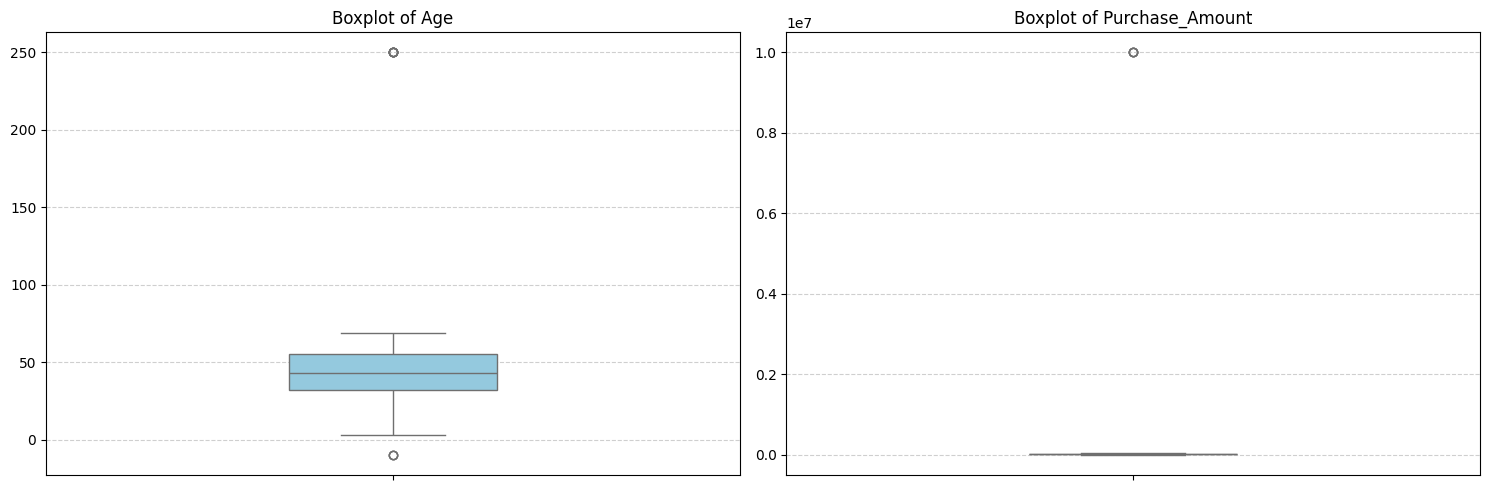

In [ ]:
from matplotlib.lines import lineStyles
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age', 'Purchase_Amount']

plt.figure(figsize=(15,5))

for i,col in enumerate(cols, 1):
  plt.subplot(1,2,i)
  sns.boxplot(y=df[col], color='skyblue', width=0.3)
  plt.title(f'Boxplot of {col}', fontsize=12)
  plt.ylabel('')
  plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

In [ ]:
import numpy as np
z_core = np.abs(stats.zscore(df[['Age', 'Purchase_Amount']]))

In [ ]:
df[(z_core > 3).any(axis=1)]

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
470,CUST6977,Tyler Stout,female,250,chennai,2022-05-21,2025-05-31,3554.0,2.0,hudsonsandra@example.net,5752427586,india
932,CUST1207,Cathy Robinson,female,250,delhi,2024-10-24,2025-10-01,23012.0,6.0,jefftaylor@example.org,1244788430,india
2383,CUST3987,Erica Johnson,male,47,kolkata,2020-11-03,2025-08-10,9999999.0,5.0,bflowers@example.com,747807729,india
2702,CUST1941,Virginia Casey,male,-10,chennai,2022-09-22,2025-01-12,3056.0,2.0,mallen@example.com,1007163131,india
3368,CUST7314,Gavin Yates,male,50,bangalore,2022-06-30,2025-03-22,9999999.0,10.0,millermichael@example.com,1481715956,india
4674,CUST8481,Denise Combs,female,62,mumbai,2024-10-06,2025-07-08,9999999.0,3.0,cmorales@example.net,2931912910,india
4692,CUST10561,Richard Brown,female,58,mumbai,2024-04-13,2025-09-08,9999999.0,2.0,kevintaylor@example.net,7047881855,india
5279,CUST4536,Alexandra Ramos,male,250,chennai,2021-09-30,2025-03-03,3296.0,10.0,drakemichelle@example.org,5651607326,india
5949,CUST7041,Joseph Young,male,250,delhi,2022-01-20,2024-11-26,1131.0,8.0,pmckenzie@example.org,9456700786,india
6085,CUST8110,Betty Cole,female,250,bangalore,2024-01-07,2025-04-12,25974.0,1.0,dmitchell@example.net,366613689,india


In [ ]:
df_clean = df[~(z_core > 3).any(axis=1)]

In [ ]:
df_clean.shape

(8986, 12)

In [ ]:
df_clean.to_csv('Customer_sales_clean_dataset')